In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost openpyxl joblib

In [2]:
import os
import re
import json
import math
import joblib
import warnings
import urllib.request

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report,
    recall_score, precision_score, f1_score
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

os.makedirs("data/nhanes", exist_ok=True)
os.makedirs("data/dryad", exist_ok=True)
os.makedirs("output", exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
NHANES_FILES = {
    "BPXO_L.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BPXO_L.XPT",
    "DEMO_L.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.XPT",
    "BMX_L.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BMX_L.XPT",
    "RXQ_RX_L.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/RXQ_RX_L.XPT",
}

for fname, url in NHANES_FILES.items():
    dest = os.path.join("data/nhanes", fname)
    if not os.path.exists(dest):
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, dest)
        print(f"✓ saved to {dest}")
    else:
        print(f"✓ already exists: {dest}")

✓ saved to data/nhanes/BPXO_L.XPT
✓ saved to data/nhanes/DEMO_L.XPT
✓ saved to data/nhanes/BMX_L.XPT
✓ saved to data/nhanes/RXQ_RX_L.XPT


In [4]:
files = [
    "data/nhanes/BPXO_L.XPT",
    "data/nhanes/DEMO_L.XPT",
    "data/nhanes/BMX_L.XPT",
    "data/nhanes/RXQ_RX_L.XPT",
]

for f in files:
    print(f"\n{f}")
    print("exists:", os.path.exists(f))
    if os.path.exists(f):
        print("size:", os.path.getsize(f), "bytes")
        with open(f, "rb") as fh:
            print("first 80 bytes:", fh.read(80))


data/nhanes/BPXO_L.XPT
exists: True
size: 696720 bytes
first 80 bytes: b'HEADER RECORD*******LIBRARY HEADER RECORD!!!!!!!000000000000000000000000000000  '

data/nhanes/DEMO_L.XPT
exists: True
size: 2582160 bytes
first 80 bytes: b'HEADER RECORD*******LIBRARY HEADER RECORD!!!!!!!000000000000000000000000000000  '

data/nhanes/BMX_L.XPT
exists: True
size: 1563200 bytes
first 80 bytes: b'HEADER RECORD*******LIBRARY HEADER RECORD!!!!!!!000000000000000000000000000000  '

data/nhanes/RXQ_RX_L.XPT
exists: True
size: 287600 bytes
first 80 bytes: b'HEADER RECORD*******LIBRARY HEADER RECORD!!!!!!!000000000000000000000000000000  '


In [6]:
DRYAD_XLSX_PATH = "data/dryad/Blood_Pressure_Sleep_Info.xlsx"
DRYAD_INFO_CSV = "data/dryad/Participant_Information.csv"

DRYAD_AVAILABLE = os.path.exists(DRYAD_XLSX_PATH)

if DRYAD_AVAILABLE:
    print(f"✓ Dryad file found: {DRYAD_XLSX_PATH}")
else:
    print("⚠ Dryad local file not found.")
    print("Place this file manually if you want real circadian calibration:")
    print("  data/dryad/Blood_Pressure_Sleep_Info.xlsx")
    print("The notebook will continue using NHANES-derived circadian proxy features.")

✓ Dryad file found: data/dryad/Blood_Pressure_Sleep_Info.xlsx


In [7]:
def decode_object_columns(df):
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(
                lambda x: x.decode("latin1").strip() if isinstance(x, (bytes, bytearray)) else x
            )
    return df

df_bp = pd.read_sas("data/nhanes/BPXO_L.XPT", format="xport", encoding="latin1")
df_rx = pd.read_sas("data/nhanes/RXQ_RX_L.XPT", format="xport", encoding="latin1")
df_demo = pd.read_sas("data/nhanes/DEMO_L.XPT", format="xport", encoding="latin1")
df_bmx = pd.read_sas("data/nhanes/BMX_L.XPT", format="xport", encoding="latin1")

df_bp = decode_object_columns(df_bp)
df_rx = decode_object_columns(df_rx)
df_demo = decode_object_columns(df_demo)
df_bmx = decode_object_columns(df_bmx)

print("Shapes:")
print("BP   :", df_bp.shape)
print("RX   :", df_rx.shape)
print("DEMO :", df_demo.shape)
print("BMX  :", df_bmx.shape)

bp_cols = [
    "SEQN", "BPXOSY1", "BPXOSY2", "BPXOSY3",
    "BPXODI1", "BPXODI1C", "BPXODI2", "BPXODI2C", "BPXODI3", "BPXODI3C",
    "BPXOPLS1", "BPXOPLS2", "BPXOPLS3", "BPXOARM"
]
demo_cols = ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "INDFMPIR", "DMDEDUC2", "RIDEXPRG"]
bmx_cols = ["SEQN", "BMXBMI", "BMXWT", "BMXHT"]

df_bp = df_bp[[c for c in bp_cols if c in df_bp.columns]]
df_demo = df_demo[[c for c in demo_cols if c in df_demo.columns]]
df_bmx = df_bmx[[c for c in bmx_cols if c in df_bmx.columns]]

print("\nBP columns:", df_bp.columns.tolist())
print("DEMO columns:", df_demo.columns.tolist())
print("BMX columns:", df_bmx.columns.tolist())
print("RX columns:", df_rx.columns.tolist())

Shapes:
BP   : (7801, 12)
RX   : (11933, 3)
DEMO : (11933, 27)
BMX  : (8860, 22)

BP columns: ['SEQN', 'BPXOSY1', 'BPXOSY2', 'BPXOSY3', 'BPXODI1', 'BPXODI2', 'BPXODI3', 'BPXOPLS1', 'BPXOPLS2', 'BPXOPLS3']
DEMO columns: ['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'INDFMPIR', 'DMDEDUC2', 'RIDEXPRG']
BMX columns: ['SEQN', 'BMXBMI', 'BMXWT', 'BMXHT']
RX columns: ['SEQN', 'RXQ033', 'RXQ050']


In [8]:
# Important note:
# RXQ_RX_L does NOT include detailed medication names in the 2021-2023 cycle.
# So we create medication usage indicators from available fields only.

if "SEQN" not in df_rx.columns:
    raise ValueError("SEQN not found in RXQ_RX_L file.")

rx_cols = ["SEQN"]
for c in ["RXDUSE", "RXDCOUNT", "RXQ050"]:
    if c in df_rx.columns:
        rx_cols.append(c)

df_rx_sub = df_rx[rx_cols].copy()

if "RXDUSE" in df_rx_sub.columns:
    df_rx_sub["antihypertensive_flag"] = df_rx_sub["RXDUSE"].apply(lambda x: 1 if pd.notna(x) and x == 1 else 0)
else:
    df_rx_sub["antihypertensive_flag"] = 0

if "RXDCOUNT" in df_rx_sub.columns:
    df_rx_sub["rx_count"] = pd.to_numeric(df_rx_sub["RXDCOUNT"], errors="coerce")
elif "RXQ050" in df_rx_sub.columns:
    df_rx_sub["rx_count"] = pd.to_numeric(df_rx_sub["RXQ050"], errors="coerce")
else:
    df_rx_sub["rx_count"] = np.nan

df_rx_sub["rx_count"] = df_rx_sub["rx_count"].fillna(0)
df_rx_sub["drug_class"] = "unknown_2021_2023"
df_rx_sub["rx_days"] = 0

df_meds = (
    df_rx_sub.groupby("SEQN", as_index=False)
    .agg({
        "antihypertensive_flag": "max",
        "rx_count": "max",
        "drug_class": "first",
        "rx_days": "max"
    })
)

print("Medication summary shape:", df_meds.shape)
print(df_meds.head())
print("\nAntihypertensive flag counts:")
print(df_meds["antihypertensive_flag"].value_counts(dropna=False))

Medication summary shape: (11933, 5)
       SEQN  antihypertensive_flag  rx_count         drug_class  rx_days
0  130378.0                      0       1.0  unknown_2021_2023        0
1  130379.0                      0       1.0  unknown_2021_2023        0
2  130380.0                      0       1.0  unknown_2021_2023        0
3  130381.0                      0       2.0  unknown_2021_2023        0
4  130382.0                      0       0.0  unknown_2021_2023        0

Antihypertensive flag counts:
antihypertensive_flag
0    11933
Name: count, dtype: int64


In [9]:
df = (
    df_bp
    .merge(df_demo, on="SEQN", how="left")
    .merge(df_bmx, on="SEQN", how="left")
    .merge(df_meds, on="SEQN", how="left")
)

df["antihypertensive_flag"] = df["antihypertensive_flag"].fillna(0).astype(int)
df["drug_class"] = df["drug_class"].fillna("unknown_2021_2023")
df["rx_days"] = df["rx_days"].fillna(0)
df["rx_count"] = df["rx_count"].fillna(0)

diastolic_candidates = [c for c in ["BPXODI1", "BPXODI2", "BPXODI3"] if c in df.columns]
if len(diastolic_candidates) < 3:
    diastolic_candidates = [c for c in ["BPXODI1C", "BPXODI2C", "BPXODI3C"] if c in df.columns]

df["sys_mean"] = df[[c for c in ["BPXOSY1", "BPXOSY2", "BPXOSY3"] if c in df.columns]].mean(axis=1)
df["dias_mean"] = df[diastolic_candidates].mean(axis=1)
df["pulse_mean"] = df[[c for c in ["BPXOPLS1", "BPXOPLS2", "BPXOPLS3"] if c in df.columns]].mean(axis=1)

df["sys_std"] = df[[c for c in ["BPXOSY1", "BPXOSY2", "BPXOSY3"] if c in df.columns]].std(axis=1)
df["dias_std"] = df[diastolic_candidates].std(axis=1)
df["pulse_pressure"] = df["sys_mean"] - df["dias_mean"]

df["baseline_sys"] = df[[c for c in ["BPXOSY1", "BPXOSY2"] if c in df.columns]].mean(axis=1)
df["new_reading"] = df["BPXOSY3"] if "BPXOSY3" in df.columns else df["sys_mean"]
df["deviation_from_baseline"] = df["new_reading"] - df["baseline_sys"]

df["age_decade"] = (df["RIDAGEYR"] // 10 * 10).astype("Int64")
df["low_income_flag"] = (df["INDFMPIR"] < 1.3).astype("Int64")
df["is_female"] = (df["RIAGENDR"] == 2).astype("Int64")

df["obesity_cat"] = pd.cut(
    df["BMXBMI"],
    bins=[0, 18.5, 25, 30, 35, 999],
    labels=["Underweight", "Normal", "Overweight", "Obese_I", "Obese_II"]
)

df["htn_stage"] = pd.cut(
    df["sys_mean"],
    bins=[0, 120, 130, 140, 160, 180, 999],
    labels=["Normal", "Elevated", "Stage1", "Stage2", "Crisis1", "Crisis2"]
)

print(df.shape)
df.head()

(7801, 37)


,SEQN,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3,BPXOPLS1,BPXOPLS2,BPXOPLS3,...,dias_std,pulse_pressure,baseline_sys,new_reading,deviation_from_baseline,age_decade,low_income_flag,is_female,obesity_cat,htn_stage
0,130378.0,135.0,131.0,132.0,98.0,96.0,94.0,82.0,79.0,82.0,...,2.000000,36.666667,133.0,132.0,-1.0,40,0,0,Overweight,Stage1
1,130379.0,121.0,117.0,113.0,84.0,76.0,76.0,72.0,71.0,73.0,...,4.618802,38.333333,119.0,113.0,-6.0,60,0,0,Obese_I,Normal
2,130380.0,111.0,112.0,104.0,79.0,80.0,76.0,84.0,83.0,77.0,...,2.081666,30.666667,111.5,104.0,-7.5,40,0,1,Overweight,Normal
3,130386.0,110.0,120.0,115.0,72.0,74.0,75.0,59.0,64.0,64.0,...,1.527525,41.333333,115.0,115.0,0.0,30,0,0,Obese_I,Normal
4,130387.0,143.0,136.0,145.0,76.0,74.0,78.0,80.0,80.0,77.0,...,2.000000,65.333333,139.5,145.0,5.5,60,0,1,Obese_II,Stage2


In [10]:
DRYAD_FEATURES_READY = False
DRYAD_CIRCADIAN_STATS = {}

if DRYAD_AVAILABLE:
    try:
        xl = pd.ExcelFile(DRYAD_XLSX_PATH)
        dryad_frames = []

        for sheet in xl.sheet_names:
            tmp = xl.parse(sheet)
            tmp["_sheet"] = sheet
            dryad_frames.append(tmp)

        df_dryad_raw = pd.concat(dryad_frames, ignore_index=True)

        lower_cols = {c: c.lower() for c in df_dryad_raw.columns}
        subj_col = next((c for c in df_dryad_raw.columns if any(k in lower_cols[c] for k in ["participant", "subject", "id", "pid"])), None)
        sys_col = next((c for c in df_dryad_raw.columns if any(k in lower_cols[c] for k in ["systol", "sbp", "sys"])), None)
        time_col = next((c for c in df_dryad_raw.columns if any(k in lower_cols[c] for k in ["time", "hour", "timestamp"])), None)
        sleep_col = next((c for c in df_dryad_raw.columns if any(k in lower_cols[c] for k in ["sleep", "wake", "rest", "state"])), None)

        print("Detected Dryad columns:")
        print("subject:", subj_col)
        print("systolic:", sys_col)
        print("time:", time_col)
        print("sleep:", sleep_col)

        if subj_col and sys_col:
            df_dryad_raw[sys_col] = pd.to_numeric(df_dryad_raw[sys_col], errors="coerce")

            def make_stats(grp):
                s = grp[sys_col].dropna()
                if len(s) < 3:
                    return pd.Series({
                        "circadian_sys_std": np.nan,
                        "morning_surge_proxy": np.nan,
                        "dipper_ratio": np.nan
                    })

                out = {
                    "circadian_sys_std": s.std(),
                    "morning_surge_proxy": s.max() - s.min()
                }

                if sleep_col:
                    asleep = grp[sleep_col].astype(str).str.lower().str.contains("sleep|asleep|night|rest", na=False)
                    night = grp.loc[asleep, sys_col].dropna()
                    day = grp.loc[~asleep, sys_col].dropna()
                elif time_col:
                    hh = pd.to_datetime(grp[time_col], errors="coerce").dt.hour
                    night = grp.loc[hh.between(0, 6, inclusive="both"), sys_col].dropna()
                    day = grp.loc[hh.between(7, 22, inclusive="both"), sys_col].dropna()
                else:
                    night = s.iloc[:max(1, len(s)//4)]
                    day = s.iloc[max(1, len(s)//4):]

                day_mean = day.mean() if len(day) else s.mean()
                night_mean = night.mean() if len(night) else s.mean()
                out["dipper_ratio"] = night_mean / day_mean if day_mean and not pd.isna(day_mean) else np.nan
                return pd.Series(out)

            df_circadian = df_dryad_raw.groupby(subj_col).apply(make_stats).reset_index()

            DRYAD_CIRCADIAN_STATS = {
                "mean_circadian_std": df_circadian["circadian_sys_std"].mean(),
                "mean_morning_surge": df_circadian["morning_surge_proxy"].mean(),
                "non_dipper_prevalence": (df_circadian["dipper_ratio"] >= 0.90).mean()
            }

            DRYAD_FEATURES_READY = True
            print("✓ Dryad calibration stats ready")
            print(DRYAD_CIRCADIAN_STATS)
        else:
            print("⚠ Could not detect required Dryad columns. Using NHANES proxies only.")
    except Exception as e:
        print("⚠ Dryad read failed:", e)
        print("Using NHANES proxies only.")

age_z = (df["RIDAGEYR"].fillna(df["RIDAGEYR"].median()) - df["RIDAGEYR"].median()) / (df["RIDAGEYR"].std() + 1e-9)
bmi_z = (df["BMXBMI"].fillna(df["BMXBMI"].median()) - df["BMXBMI"].median()) / (df["BMXBMI"].std() + 1e-9)
std_z = (df["sys_std"].fillna(df["sys_std"].median()) - df["sys_std"].median()) / (df["sys_std"].std() + 1e-9)
no_med = 1 - df["antihypertensive_flag"]

df["sys_cv"] = (df["sys_std"] / df["sys_mean"].replace(0, np.nan)) * 100
df["pp_variability"] = (df["pulse_pressure"] / df["sys_mean"].replace(0, np.nan)) * 100
df["morning_surge_proxy"] = 0.40 * age_z + 0.25 * bmi_z + 0.25 * std_z + 0.10 * no_med

is_black_aa = (df["RIDRETH3"] == 4).astype(int)
high_bp_flag = (df["sys_mean"] > 140).astype(int)
df["non_dipper_risk"] = 0.35 * is_black_aa + 0.30 * age_z.clip(-3, 3) / 3 + 0.25 * high_bp_flag + 0.10 * no_med
df["circadian_dysreg_index"] = df["sys_cv"].fillna(0) / 10 + df["non_dipper_risk"].fillna(0)

if DRYAD_FEATURES_READY:
    surge_scale = DRYAD_CIRCADIAN_STATS["mean_morning_surge"] / (df["morning_surge_proxy"].mean() + 1e-9)
    nd_scale = DRYAD_CIRCADIAN_STATS["non_dipper_prevalence"] / (df["non_dipper_risk"].mean() + 1e-9)

    df["morning_surge_proxy"] = df["morning_surge_proxy"] * surge_scale
    df["non_dipper_risk"] = df["non_dipper_risk"] * nd_scale
    df["circadian_dysreg_index"] = df["sys_cv"].fillna(0) / 10 + df["non_dipper_risk"].fillna(0)

print(df[["sys_cv", "pp_variability", "morning_surge_proxy", "non_dipper_risk", "circadian_dysreg_index"]].describe())

Detected Dryad columns:
subject: ID
systolic: Systolic
time: Time
sleep: Wake_Sleep
✓ Dryad calibration stats ready
{'mean_circadian_std': np.float64(52.67103611246707), 'mean_morning_surge': np.float64(144.16666666666666), 'non_dipper_prevalence': np.float64(1.0)}
            sys_cv  pp_variability  morning_surge_proxy  non_dipper_risk  \
count  7506.000000     7518.000000          7801.000000      7801.000000   
mean      3.191651       39.021641           144.166666         1.000000   
std       2.570195        7.152876           559.941636         1.138142   
min       0.000000       19.130435         -1189.242762        -0.436646   
25%       1.603751       34.078225          -283.058549         0.099862   
50%       2.606392       38.481675           202.993518         0.877799   
75%       4.028485       43.478261           547.120571         1.467958   
max      33.930499       67.821782          3074.854922         5.152051   

       circadian_dysreg_index  
count            

In [11]:
n_before = len(df)

preg_mask = True
if "RIDEXPRG" in df.columns:
    preg_mask = (df["RIDEXPRG"].fillna(0) != 1)

mask = (
    (df["RIDAGEYR"] >= 35) &
    (df["sys_mean"] >= 120) &
    df["BPXOSY1"].notna() &
    df["BPXOSY2"].notna() &
    preg_mask
)

df_filtered = df[mask].copy().reset_index(drop=True)

print(f"Before filtering: {n_before:,}")
print(f"After filtering : {len(df_filtered):,}")
print(df_filtered["htn_stage"].value_counts(dropna=False))

Before filtering: 7,801
After filtering : 2,741
htn_stage
Elevated    1092
Stage1       743
Stage2       658
Crisis1      155
Crisis2       52
Normal        41
Name: count, dtype: int64


In [12]:
df_filtered["target"] = (
    (df_filtered["new_reading"] > 160) |
    (df_filtered["deviation_from_baseline"] > 20)
).astype(int)

print(df_filtered["target"].value_counts())
print(f"Positive rate: {df_filtered['target'].mean()*100:.2f}%")

target
0    2526
1     215
Name: count, dtype: int64
Positive rate: 7.84%


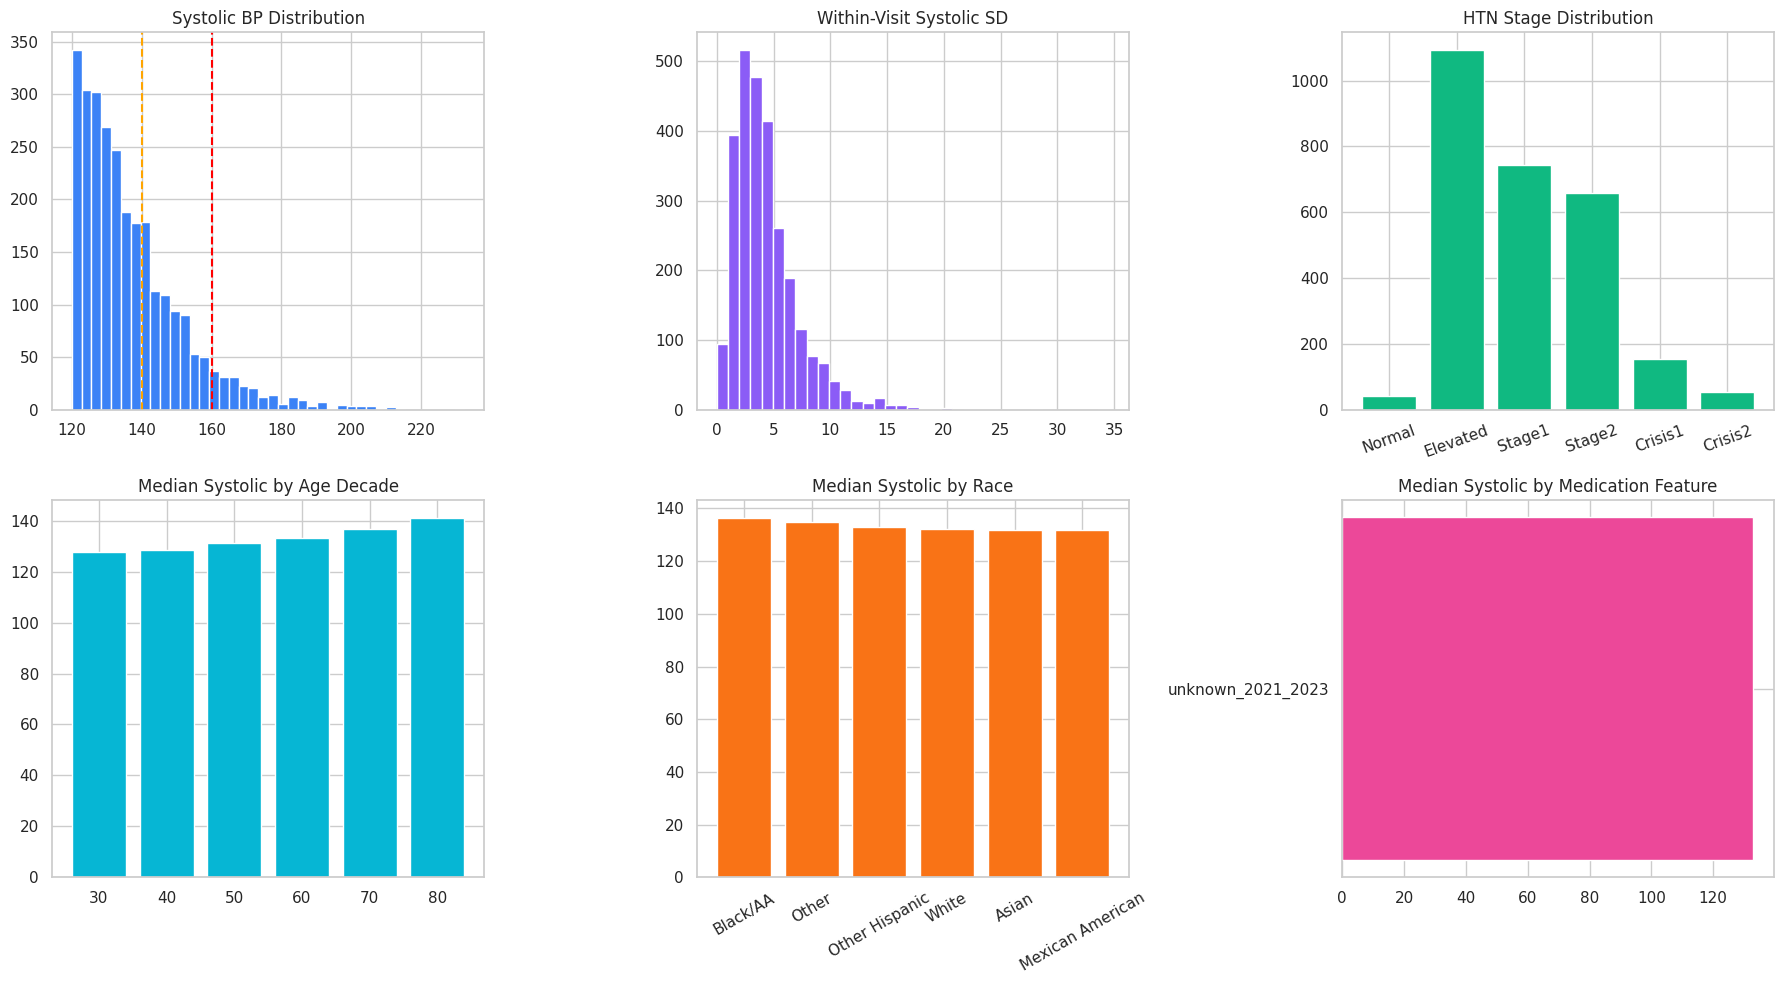

In [13]:
RACE_MAP = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "White",
    4: "Black/AA",
    6: "Asian",
    7: "Other"
}
df_filtered["race_label"] = df_filtered["RIDRETH3"].map(RACE_MAP).fillna("Unknown")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].hist(df_filtered["sys_mean"].dropna(), bins=40, color="#3b82f6", edgecolor="white")
axes[0,0].axvline(140, color="orange", linestyle="--")
axes[0,0].axvline(160, color="red", linestyle="--")
axes[0,0].set_title("Systolic BP Distribution")

axes[0,1].hist(df_filtered["sys_std"].dropna(), bins=35, color="#8b5cf6", edgecolor="white")
axes[0,1].set_title("Within-Visit Systolic SD")

stage_counts = df_filtered["htn_stage"].value_counts().sort_index()
axes[0,2].bar(stage_counts.index.astype(str), stage_counts.values, color="#10b981")
axes[0,2].set_title("HTN Stage Distribution")
axes[0,2].tick_params(axis="x", rotation=20)

age_bp = df_filtered.groupby("age_decade")["sys_mean"].median()
axes[1,0].bar(age_bp.index.astype(str), age_bp.values, color="#06b6d4")
axes[1,0].set_title("Median Systolic by Age Decade")

race_bp = df_filtered.groupby("race_label")["sys_mean"].median().sort_values(ascending=False)
axes[1,1].bar(race_bp.index, race_bp.values, color="#f97316")
axes[1,1].set_title("Median Systolic by Race")
axes[1,1].tick_params(axis="x", rotation=30)

drug_bp = df_filtered.groupby("drug_class")["sys_mean"].median().sort_values()
axes[1,2].barh(drug_bp.index.astype(str), drug_bp.values, color="#ec4899")
axes[1,2].set_title("Median Systolic by Medication Feature")

plt.tight_layout()
plt.savefig("output/eda_part1.png", dpi=150, bbox_inches="tight")
plt.show()

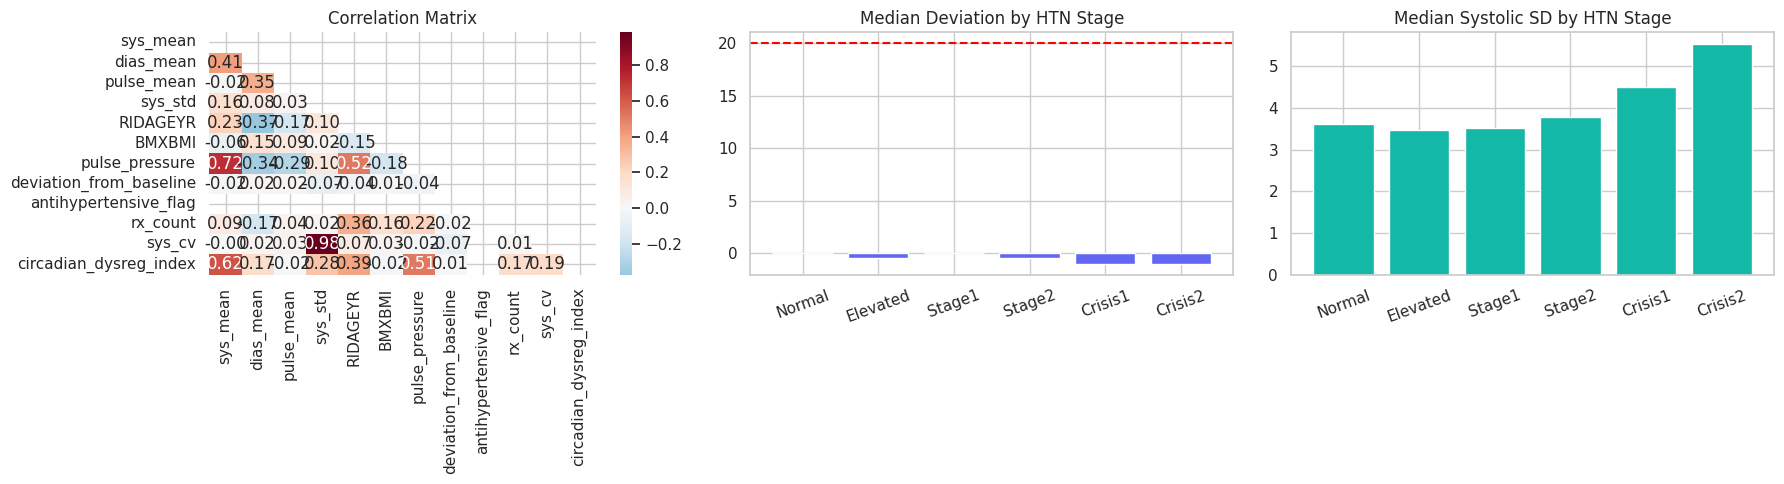

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

num_cols = [
    "sys_mean", "dias_mean", "pulse_mean", "sys_std", "RIDAGEYR", "BMXBMI",
    "pulse_pressure", "deviation_from_baseline", "antihypertensive_flag",
    "rx_count", "sys_cv", "circadian_dysreg_index"
]
num_cols = [c for c in num_cols if c in df_filtered.columns]

corr = df_filtered[num_cols].corr()
mask_upper = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_upper, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_title("Correlation Matrix")

stage_order = ["Normal", "Elevated", "Stage1", "Stage2", "Crisis1", "Crisis2"]
med_dev = [df_filtered.loc[df_filtered["htn_stage"] == s, "deviation_from_baseline"].median() for s in stage_order]
axes[1].bar(stage_order, med_dev, color="#6366f1")
axes[1].axhline(20, color="red", linestyle="--")
axes[1].set_title("Median Deviation by HTN Stage")
axes[1].tick_params(axis="x", rotation=20)

med_var = [df_filtered.loc[df_filtered["htn_stage"] == s, "sys_std"].median() for s in stage_order]
axes[2].bar(stage_order, med_var, color="#14b8a6")
axes[2].set_title("Median Systolic SD by HTN Stage")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("output/eda_part2.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
le = LabelEncoder()
df_filtered["drug_class_enc"] = le.fit_transform(df_filtered["drug_class"].astype(str))

FEATURE_COLS = [
    "RIDAGEYR",
    "is_female",
    "RIDRETH3",
    "BMXBMI",
    "INDFMPIR",
    "DMDEDUC2",
    "sys_std",
    "baseline_sys",
    "dias_mean",
    "pulse_mean",
    "pulse_pressure",
    "antihypertensive_flag",
    "rx_count",
    "rx_days",
    "morning_surge_proxy",
    "low_income_flag",
    "drug_class_enc",
    "sys_cv",
    "pp_variability",
    "non_dipper_risk",
    "circadian_dysreg_index"
]

FEATURE_COLS = [c for c in FEATURE_COLS if c in df_filtered.columns]

X = df_filtered[FEATURE_COLS].copy()
y = df_filtered["target"].copy()

valid_rows = X.isnull().mean(axis=1) < 0.5
X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()

numeric_medians = X.median(numeric_only=True)
X = X.fillna(numeric_medians)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train positive rate:", y_train.mean())
print("Test positive rate :", y_test.mean())

Train shape: (2192, 21)
Test shape : (549, 21)
Train positive rate: 0.07846715328467153
Test positive rate : 0.07832422586520947


In [16]:
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="aucpr",
    early_stopping_rounds=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("Best iteration:", xgb_model.best_iteration)

Best iteration: 14


In [17]:
y_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred_05 = (y_proba >= 0.5).astype(int)

precision_arr, recall_arr, threshold_arr = precision_recall_curve(y_test, y_proba)

idx_90 = np.where(recall_arr >= 0.90)[0]
if len(idx_90) > 0 and len(threshold_arr) > 0:
    best_idx = idx_90[-1]
    operational_threshold = threshold_arr[min(best_idx, len(threshold_arr)-1)]
    precision_at_90 = precision_arr[min(best_idx, len(precision_arr)-1)]
else:
    operational_threshold = 0.5
    precision_at_90 = precision_score(y_test, y_pred_05, zero_division=0)

y_pred_ops = (y_proba >= operational_threshold).astype(int)

auc_roc = roc_auc_score(y_test, y_proba)
auc_pr = average_precision_score(y_test, y_proba)
sens = recall_score(y_test, y_pred_ops)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ops).ravel()
spec = tn / (tn + fp + 1e-9)

test_sys = df_filtered.loc[X_test.index, "sys_mean"]
bench_140 = (test_sys >= 140).astype(int)
bench_130 = (test_sys >= 130).astype(int)
bench_rule = (
    (df_filtered.loc[X_test.index, "new_reading"] > 160) |
    (df_filtered.loc[X_test.index, "deviation_from_baseline"] > 20)
).astype(int)

def binary_eval(y_true, y_pred):
    auc = roc_auc_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_true, y_pred).ravel()
    spc = tn_ / (tn_ + fp_ + 1e-9)
    return auc, rec, spc

a140, r140, s140 = binary_eval(y_test, bench_140)
a130, r130, s130 = binary_eval(y_test, bench_130)
arule, rrule, srule = binary_eval(y_test, bench_rule)

print("XGBoost metrics")
print("AUC-ROC              :", round(auc_roc, 4))
print("AUC-PR               :", round(auc_pr, 4))
print("Sensitivity          :", round(sens, 4))
print("Specificity          :", round(spec, 4))
print("Precision @ 90% rec  :", round(precision_at_90, 4))
print("Operational threshold:", round(float(operational_threshold), 4))
print()
print(classification_report(y_test, y_pred_05, target_names=["Normal", "Alert"]))

benchmark_df = pd.DataFrame({
    "Model": ["Fixed 140/90", "ACC/AHA 130/80", "Rule Engine", "XGBoost"],
    "AUC_ROC": [a140, a130, arule, auc_roc],
    "Sensitivity": [r140, r130, rrule, sens],
    "Specificity": [s140, s130, srule, spec]
})
benchmark_df

XGBoost metrics
AUC-ROC              : 0.9951
AUC-PR               : 0.9483
Sensitivity          : 0.907
Specificity          : 0.9783
Precision @ 90% rec  : 0.78
Operational threshold: 0.6027

              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98       506
       Alert       0.67      0.98      0.79        43

    accuracy                           0.96       549
   macro avg       0.83      0.97      0.89       549
weighted avg       0.97      0.96      0.96       549



,Model,AUC_ROC,Sensitivity,Specificity
0,Fixed 140/90,0.868577,1.000000,0.737154
1,ACC/AHA 130/80,0.702569,1.000000,0.405138
2,Rule Engine,1.000000,1.000000,1.000000
3,XGBoost,0.995128,0.906977,0.978261


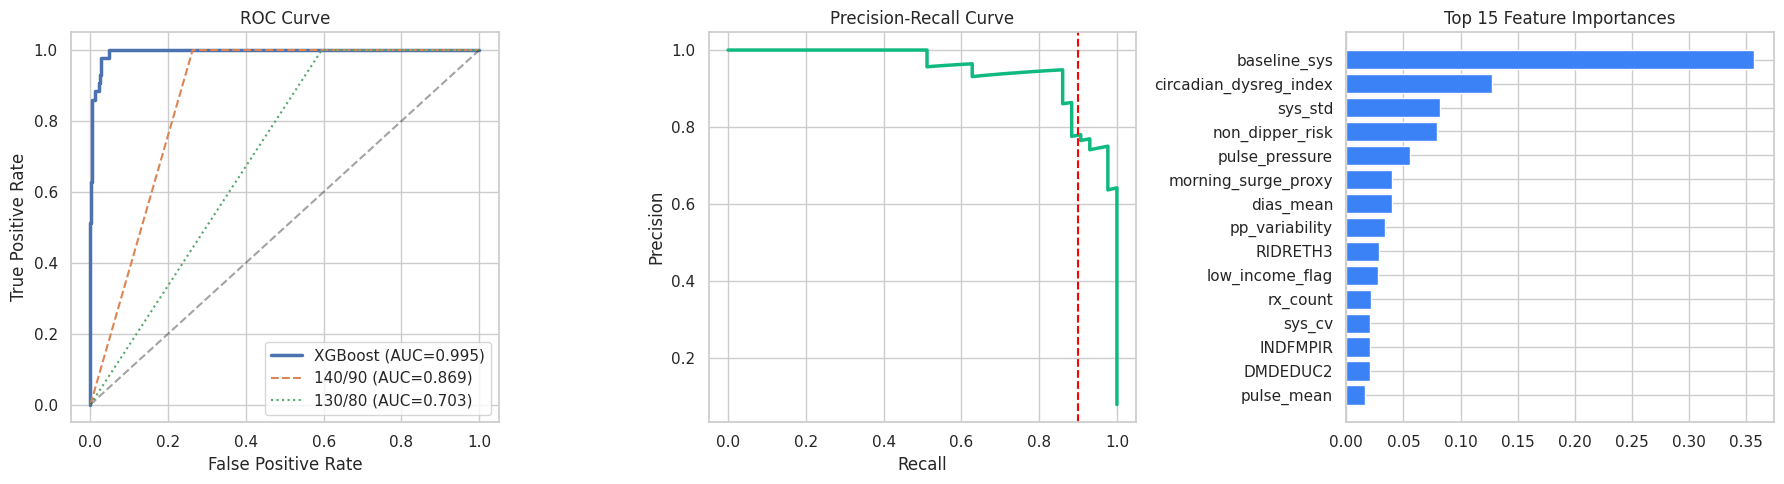

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
fpr140, tpr140, _ = roc_curve(y_test, bench_140)
fpr130, tpr130, _ = roc_curve(y_test, bench_130)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, label=f"XGBoost (AUC={auc_roc:.3f})", linewidth=2.5)
axes[0].plot(fpr140, tpr140, "--", label=f"140/90 (AUC={a140:.3f})")
axes[0].plot(fpr130, tpr130, ":", label=f"130/80 (AUC={a130:.3f})")
axes[0].plot([0,1],[0,1], "k--", alpha=0.4)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(recall_arr, precision_arr, color="#10b981", linewidth=2.5)
axes[1].axvline(0.90, color="red", linestyle="--")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

fi = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False).head(15)
axes[2].barh(fi.index[::-1], fi.values[::-1], color="#3b82f6")
axes[2].set_title("Top 15 Feature Importances")

plt.tight_layout()
plt.savefig("output/xgboost_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
contamination_rate = float(y.mean())

iso_model = IsolationForest(
    n_estimators=300,
    contamination=contamination_rate,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

iso_model.fit(X_train_scaled)

iso_test_pred = iso_model.predict(X_test_scaled)
iso_test_scores = iso_model.decision_function(X_test_scaled)

iso_binary = (iso_test_pred == -1).astype(int)
iso_auc_roc = roc_auc_score(y_test, -iso_test_scores)
iso_auc_pr = average_precision_score(y_test, -iso_test_scores)
iso_recall = recall_score(y_test, iso_binary)
iso_precision = precision_score(y_test, iso_binary, zero_division=0)
iso_f1 = f1_score(y_test, iso_binary, zero_division=0)

tn, fp, fn, tp = confusion_matrix(y_test, iso_binary).ravel()
iso_spec = tn / (tn + fp + 1e-9)

print("Isolation Forest metrics")
print("AUC-ROC   :", round(iso_auc_roc, 4))
print("AUC-PR    :", round(iso_auc_pr, 4))
print("Recall    :", round(iso_recall, 4))
print("Precision :", round(iso_precision, 4))
print("F1        :", round(iso_f1, 4))
print("Specificity:", round(iso_spec, 4))

Isolation Forest metrics
AUC-ROC   : 0.8584
AUC-PR    : 0.3854
Recall    : 0.5349
Precision : 0.434
F1        : 0.4792
Specificity: 0.9407


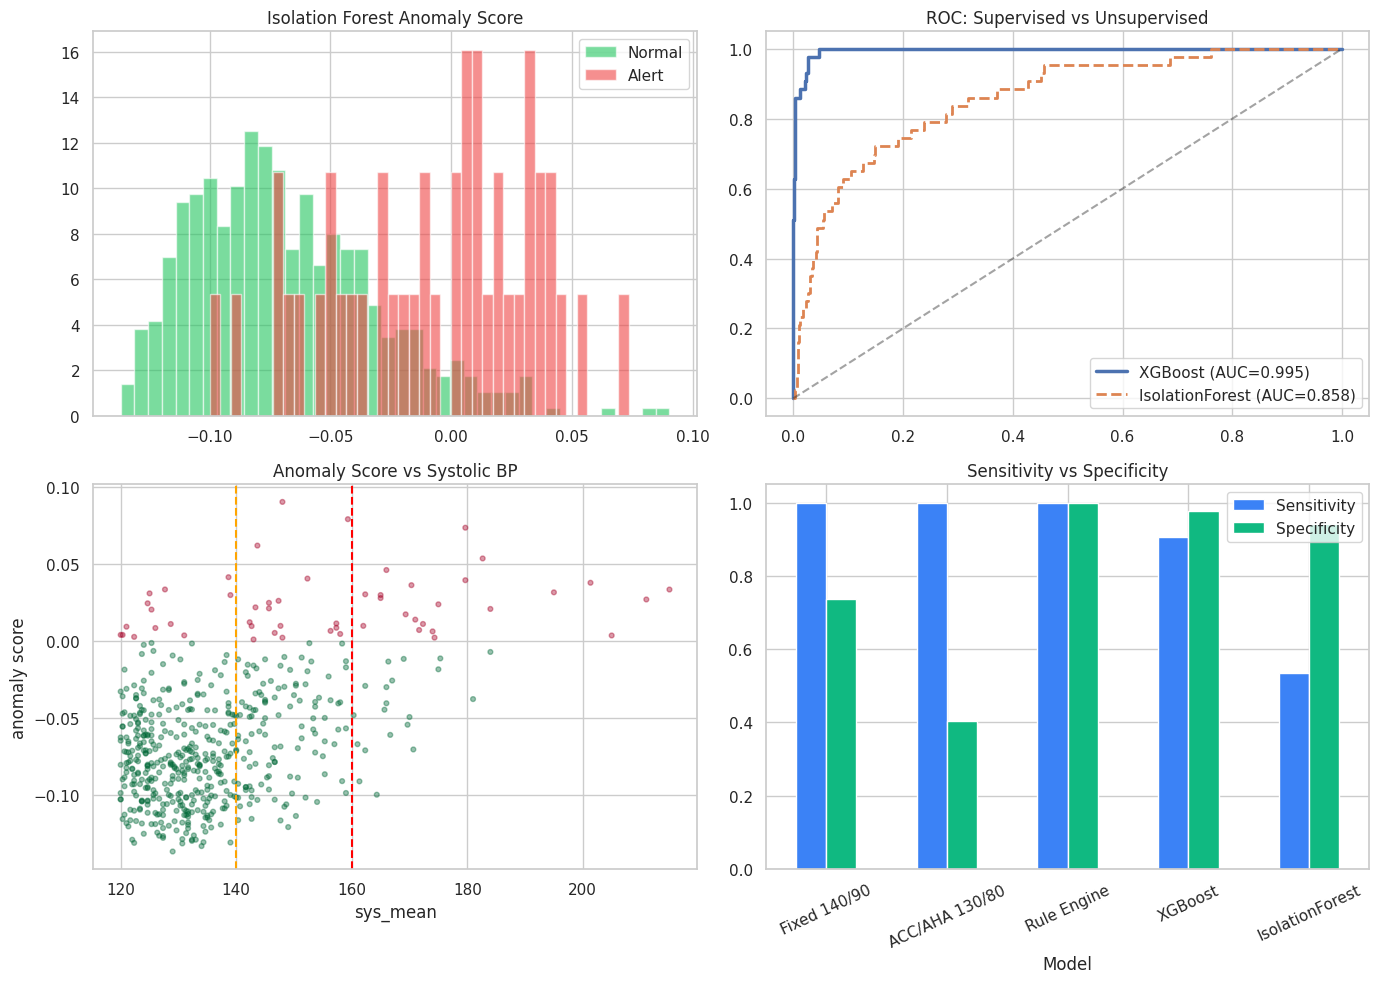

     race_ethnicity    n  alert_rate  xgb_auc_roc  xgb_sensitivity  \
0             White  334      0.0599       0.9955           0.8500   
1          Black/AA   75      0.1067       0.9981           1.0000   
2             Asian   28      0.1429       0.9896           1.0000   
3  Mexican American   33      0.0000          NaN           0.0000   
4    Other Hispanic   47      0.1489       0.9964           0.8571   
5             Other   32      0.1250       1.0000           1.0000   

   xgb_specificity  
0           0.9809  
1           0.9552  
2           0.9583  
3           1.0000  
4           1.0000  
5           0.9643  


{'xgboost_probability': 0.6865,
 'xgboost_alert': True,
 'isolation_forest_score': -0.0201,
 'isolation_forest_alert': True,
 'consensus': 'HIGH_CONFIDENCE_ALERT'}

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(-iso_test_scores[y_test == 0], bins=40, alpha=0.6, label="Normal", color="#22c55e", density=True)
axes[0,0].hist(-iso_test_scores[y_test == 1], bins=40, alpha=0.6, label="Alert", color="#ef4444", density=True)
axes[0,0].set_title("Isolation Forest Anomaly Score")
axes[0,0].legend()

fpr_iso, tpr_iso, _ = roc_curve(y_test, -iso_test_scores)
axes[0,1].plot(fpr, tpr, label=f"XGBoost (AUC={auc_roc:.3f})", linewidth=2.5)
axes[0,1].plot(fpr_iso, tpr_iso, label=f"IsolationForest (AUC={iso_auc_roc:.3f})", linewidth=2.0, linestyle="--")
axes[0,1].plot([0,1],[0,1], "k--", alpha=0.4)
axes[0,1].set_title("ROC: Supervised vs Unsupervised")
axes[0,1].legend()

sys_test = df_filtered.loc[X_test.index, "sys_mean"]
axes[1,0].scatter(sys_test, -iso_test_scores, s=12, alpha=0.4, c=iso_binary, cmap="RdYlGn_r")
axes[1,0].axvline(140, color="orange", linestyle="--")
axes[1,0].axvline(160, color="red", linestyle="--")
axes[1,0].set_title("Anomaly Score vs Systolic BP")
axes[1,0].set_xlabel("sys_mean")
axes[1,0].set_ylabel("anomaly score")

compare_df = pd.DataFrame({
    "Model": ["Fixed 140/90", "ACC/AHA 130/80", "Rule Engine", "XGBoost", "IsolationForest"],
    "Sensitivity": [r140, r130, rrule, sens, iso_recall],
    "Specificity": [s140, s130, srule, spec, iso_spec]
})
compare_df.plot(x="Model", y=["Sensitivity", "Specificity"], kind="bar", ax=axes[1,1], color=["#3b82f6", "#10b981"])
axes[1,1].set_title("Sensitivity vs Specificity")
axes[1,1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig("output/isolation_forest_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

race_test = df_filtered.loc[X_test.index, "RIDRETH3"].map(RACE_MAP).fillna("Unknown")
rows = []

for grp in race_test.dropna().unique():
    idx = (race_test == grp).values
    if idx.sum() < 20:
        continue

    yt = y_test.values[idx]
    yp = y_proba[idx]
    yo = y_pred_ops[idx]

    if len(np.unique(yt)) > 1:
        auc_grp = roc_auc_score(yt, yp)
    else:
        auc_grp = np.nan

    sens_grp = recall_score(yt, yo, zero_division=0)

    cm = confusion_matrix(yt, yo, labels=[0, 1])
    tn_, fp_, fn_, tp_ = cm.ravel()
    spec_grp = tn_ / (tn_ + fp_ + 1e-9)

    rows.append({
        "race_ethnicity": grp,
        "n": int(idx.sum()),
        "alert_rate": round(float(yt.mean()), 4),
        "xgb_auc_roc": round(float(auc_grp), 4) if not np.isnan(auc_grp) else np.nan,
        "xgb_sensitivity": round(float(sens_grp), 4),
        "xgb_specificity": round(float(spec_grp), 4)
    })

bias_df = pd.DataFrame(rows)
bias_df.to_csv("output/bias_monitoring.csv", index=False)
print(bias_df)

joblib.dump(xgb_model, "output/healplace_xgboost.pkl")
joblib.dump(iso_model, "output/healplace_isolation_forest.pkl")
joblib.dump(scaler, "output/healplace_scaler.pkl")
joblib.dump(le, "output/healplace_drug_class_encoder.pkl")

def preprocess_patient(patient):
    sys_vals = [patient["sys1"], patient["sys2"], patient["sys3"]]
    dia_vals = [patient["dias1"], patient["dias2"], patient["dias3"]]
    pulse_vals = [patient["pulse1"], patient["pulse2"], patient["pulse3"]]

    sys_mean = np.mean(sys_vals)
    dias_mean = np.mean(dia_vals)
    sys_std = np.std(sys_vals, ddof=1) if len(sys_vals) > 1 else 0
    baseline_sys = np.mean([patient["sys1"], patient["sys2"]])
    pulse_mean = np.mean(pulse_vals)
    pulse_pressure = sys_mean - dias_mean
    sys_cv = (sys_std / sys_mean * 100) if sys_mean else 0
    pp_variability = (pulse_pressure / sys_mean * 100) if sys_mean else 0

    age = patient.get("age", 55)
    bmi = patient.get("bmi", 28.0)
    age_z_ = (age - df_filtered["RIDAGEYR"].median()) / (df_filtered["RIDAGEYR"].std() + 1e-9)
    bmi_z_ = (bmi - df_filtered["BMXBMI"].median()) / (df_filtered["BMXBMI"].std() + 1e-9)
    std_z_ = (sys_std - df_filtered["sys_std"].median()) / (df_filtered["sys_std"].std() + 1e-9)

    no_med_ = 1 - int(patient.get("on_recent_rx", 0))
    is_black = 1 if patient.get("race_code", 3) == 4 else 0

    morning_surge_proxy = 0.40 * age_z_ + 0.25 * bmi_z_ + 0.25 * std_z_ + 0.10 * no_med_
    non_dipper_risk = 0.35 * is_black + 0.30 * np.clip(age_z_, -3, 3) / 3 + 0.25 * int(sys_mean > 140) + 0.10 * no_med_
    circadian_dysreg_index = sys_cv / 10 + non_dipper_risk

    drug_class = "unknown_2021_2023"
    drug_class_enc = le.transform([drug_class])[0] if drug_class in le.classes_ else 0

    row = {
        "RIDAGEYR": age,
        "is_female": int(patient.get("gender", "M") == "F"),
        "RIDRETH3": patient.get("race_code", 3),
        "BMXBMI": bmi,
        "INDFMPIR": patient.get("income_pir", 1.5),
        "DMDEDUC2": patient.get("education", 3),
        "sys_std": sys_std,
        "baseline_sys": baseline_sys,
        "dias_mean": dias_mean,
        "pulse_mean": pulse_mean,
        "pulse_pressure": pulse_pressure,
        "antihypertensive_flag": int(patient.get("on_recent_rx", 0)),
        "rx_count": patient.get("rx_count", 0),
        "rx_days": 0,
        "morning_surge_proxy": morning_surge_proxy,
        "low_income_flag": int(patient.get("income_pir", 1.5) < 1.3),
        "drug_class_enc": drug_class_enc,
        "sys_cv": sys_cv,
        "pp_variability": pp_variability,
        "non_dipper_risk": non_dipper_risk,
        "circadian_dysreg_index": circadian_dysreg_index
    }

    Xp = pd.DataFrame([row])[FEATURE_COLS].fillna(numeric_medians.reindex(FEATURE_COLS).fillna(0))
    return Xp

def predict_patient(patient, threshold=operational_threshold):
    Xp = preprocess_patient(patient)
    Xp_scaled = scaler.transform(Xp)

    xgb_prob = xgb_model.predict_proba(Xp)[0, 1]
    xgb_alert = int(xgb_prob >= threshold)

    iso_pred = iso_model.predict(Xp_scaled)[0]
    iso_alert = int(iso_pred == -1)
    iso_score = iso_model.decision_function(Xp_scaled)[0]

    consensus = (
        "HIGH_CONFIDENCE_ALERT" if (xgb_alert == 1 and iso_alert == 1)
        else "ALERT" if (xgb_alert == 1 or iso_alert == 1)
        else "NORMAL"
    )

    return {
        "xgboost_probability": round(float(xgb_prob), 4),
        "xgboost_alert": bool(xgb_alert),
        "isolation_forest_score": round(float(iso_score), 4),
        "isolation_forest_alert": bool(iso_alert),
        "consensus": consensus
    }

demo_patient = {
    "age": 71,
    "gender": "F",
    "race_code": 4,
    "bmi": 35.8,
    "income_pir": 0.8,
    "education": 2,
    "sys1": 170, "sys2": 174, "sys3": 183,
    "dias1": 102, "dias2": 106, "dias3": 110,
    "pulse1": 84, "pulse2": 86, "pulse3": 88,
    "on_recent_rx": 0,
    "rx_count": 0
}

predict_patient(demo_patient)